In [1]:
pip install yfinance pandas numpy matplotlib seaborn requests

Note: you may need to restart the kernel to use updated packages.


In [2]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from datetime import datetime, timedelta
import warnings
warnings.filterwarnings('ignore')

print("All libraries loaded successfully")

Matplotlib is building the font cache; this may take a moment.


All libraries loaded successfully


In [3]:
# ============================================================
# SECTION 1: SECTOR ROTATION DASHBOARD
# ============================================================

# Define all 11 S&P 500 sector ETFs
sectors = {
    'XLK':  'Technology',
    'XLF':  'Financials',
    'XLV':  'Health Care',
    'XLE':  'Energy',
    'XLI':  'Industrials',
    'XLY':  'Consumer Disc.',
    'XLP':  'Consumer Staples',
    'XLU':  'Utilities',
    'XLB':  'Materials',
    'XLRE': 'Real Estate',
    'XLC':  'Comm. Services'
}

# Pull 3 months of price data
end = datetime.today()
start = end - timedelta(days=90)

print("Fetching sector data...")
raw = yf.download(list(sectors.keys()), start=start, end=end, auto_adjust=True, progress=False)
prices = raw['Close']
print(f"Got {len(prices)} trading days of data")
print(prices.tail(3))

Fetching sector data...



1 Failed download:
['XLK']: OperationalError('database is locked')


Got 63 trading days of data
Ticker         XLB         XLC        XLE        XLF         XLI  XLK  \
Date                                                                    
2026-06-12  52.180  111.650002  57.549999  53.340000  176.179993  NaN   
2026-06-15     NaN  112.190002        NaN        NaN         NaN  NaN   
2026-06-16  52.715  111.970001  55.209999  54.224998  180.300003  NaN   

Ticker            XLP       XLRE        XLU         XLV         XLY  
Date                                                                 
2026-06-12  85.820000  45.360001  44.529999  153.809998  116.599998  
2026-06-15        NaN  44.990002        NaN         NaN         NaN  
2026-06-16  85.855003  45.084999  45.270000  152.750000  119.120003  


In [4]:
# Drop XLK since it failed to download, remove any empty rows
prices = prices.drop(columns=['XLK']).dropna(how='all').ffill()

# Remove XLK from sectors dict too
sectors.pop('XLK')

# Calculate returns over 1W, 1M, 3M
def get_return(df, days):
    return ((df.iloc[-1] - df.iloc[-days]) / df.iloc[-days] * 100).round(2)

returns = pd.DataFrame({
    '1W Return %':  get_return(prices, 5),
    '1M Return %':  get_return(prices, 21),
    '3M Return %':  get_return(prices, 63)
})

# Map tickers to full sector names
returns.index = [sectors[t] for t in returns.index]
returns = returns.sort_values('1M Return %', ascending=False)

print(returns)

                  1W Return %  1M Return %  3M Return %
Industrials              6.27         5.59         9.46
Materials                6.28         4.97         9.22
Health Care             -0.07         4.82         4.24
Financials               3.82         4.80        11.30
Real Estate              0.21         3.05         8.02
Utilities                2.89         3.03        -2.45
Consumer Disc.           4.96         2.41         7.95
Consumer Staples         0.43        -0.05         4.48
Comm. Services           0.86        -4.28        -1.17
Energy                  -5.22        -8.86        -4.89


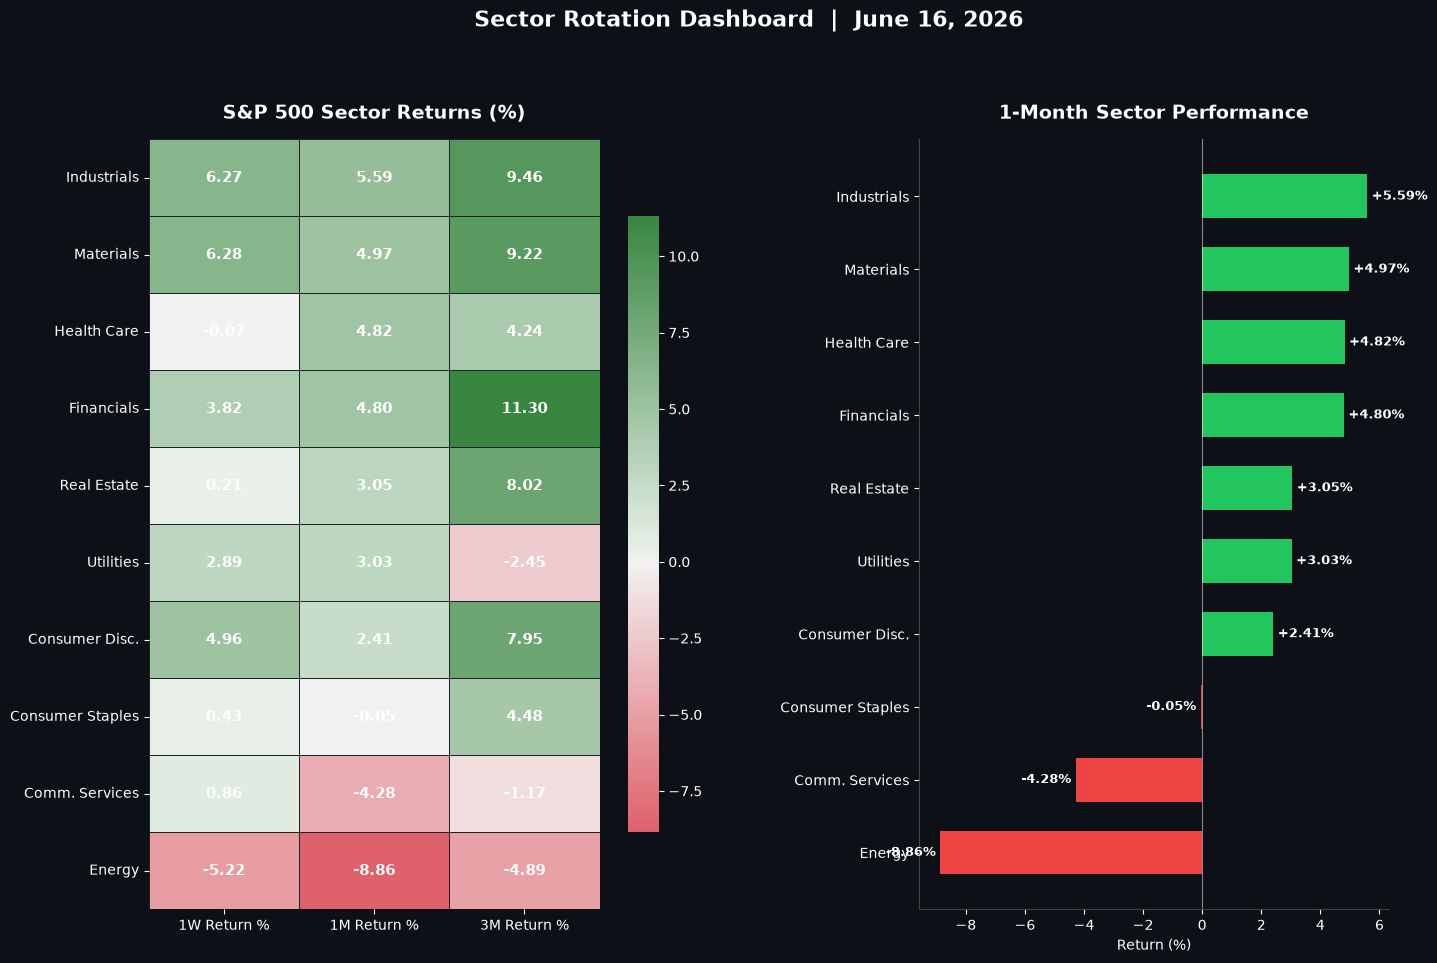

Chart saved as sector_rotation.png


In [5]:
# ============================================================
# SECTOR ROTATION HEATMAP + BAR CHART
# ============================================================

fig = plt.figure(figsize=(16, 10))
fig.patch.set_facecolor('#0d1117')
gs = gridspec.GridSpec(1, 2, width_ratios=[1.2, 1], wspace=0.4)

# --- LEFT: Heatmap ---
ax1 = fig.add_subplot(gs[0])
ax1.set_facecolor('#0d1117')

cmap = sns.diverging_palette(10, 130, as_cmap=True)
sns.heatmap(
    returns,
    annot=True,
    fmt=".2f",
    cmap=cmap,
    center=0,
    linewidths=0.5,
    linecolor='#1c2128',
    ax=ax1,
    cbar_kws={'shrink': 0.8},
    annot_kws={'size': 11, 'weight': 'bold', 'color': 'white'}
)

ax1.set_title('S&P 500 Sector Returns (%)', color='white', fontsize=14, fontweight='bold', pad=15)
ax1.tick_params(colors='white', labelsize=10)
ax1.xaxis.label.set_color('white')
ax1.yaxis.label.set_color('white')
plt.setp(ax1.get_xticklabels(), color='white')
plt.setp(ax1.get_yticklabels(), color='white', rotation=0)

# Colorbar text
cbar = ax1.collections[0].colorbar
cbar.ax.tick_params(colors='white')

# --- RIGHT: 1M Horizontal Bar Chart ---
ax2 = fig.add_subplot(gs[1])
ax2.set_facecolor('#0d1117')
fig.patch.set_facecolor('#0d1117')

sorted_1m = returns['1M Return %'].sort_values()
colors = ['#ef4444' if x < 0 else '#22c55e' for x in sorted_1m]

bars = ax2.barh(sorted_1m.index, sorted_1m.values, color=colors, edgecolor='none', height=0.6)

# Add value labels
for bar, val in zip(bars, sorted_1m.values):
    ax2.text(
        val + (0.15 if val >= 0 else -0.15),
        bar.get_y() + bar.get_height() / 2,
        f'{val:+.2f}%',
        va='center',
        ha='left' if val >= 0 else 'right',
        color='white',
        fontsize=9,
        fontweight='bold'
    )

ax2.axvline(0, color='white', linewidth=0.8, alpha=0.5)
ax2.set_title('1-Month Sector Performance', color='white', fontsize=14, fontweight='bold', pad=15)
ax2.tick_params(colors='white', labelsize=10)
ax2.set_xlabel('Return (%)', color='white', fontsize=10)
plt.setp(ax2.get_yticklabels(), color='white')
ax2.spines['bottom'].set_color('#444')
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)
ax2.spines['left'].set_color('#444')
ax2.set_facecolor('#0d1117')

today = datetime.today().strftime('%B %d, %Y')
fig.suptitle(f'Sector Rotation Dashboard  |  {today}', color='white', fontsize=16, fontweight='bold', y=1.01)

plt.savefig('sector_rotation.png', dpi=150, bbox_inches='tight', facecolor='#0d1117')
plt.show()
print("Chart saved as sector_rotation.png")

In [6]:
# ============================================================
# SECTION 2: EARNINGS SURPRISE TRACKER
# ============================================================

# High-profile tickers with recent earnings
tickers = ['AAPL', 'MSFT', 'GOOGL', 'META', 'AMZN', 'NVDA', 'JPM', 'GS', 'WMT', 'TGT']

print("Fetching earnings data...")

earnings_data = []

for ticker in tickers:
    try:
        stock = yf.Ticker(ticker)
        earnings = stock.earnings_dates
        
        if earnings is None or earnings.empty:
            continue
            
        # Get most recent past earnings
        past = earnings[earnings.index < pd.Timestamp.today(tz='America/New_York')]
        
        if past.empty:
            continue
            
        latest = past.iloc[0]
        
        eps_est = latest.get('EPS Estimate')
        eps_act = latest.get('Reported EPS')
        surprise = latest.get('Surprise(%)')
        date = past.index[0].strftime('%Y-%m-%d')
        
        if pd.isna(eps_est) or pd.isna(eps_act):
            continue
            
        earnings_data.append({
            'Ticker': ticker,
            'Date': date,
            'EPS Estimate': round(eps_est, 2),
            'Reported EPS': round(eps_act, 2),
            'Surprise %': round(surprise, 2) if not pd.isna(surprise) else round((eps_act - eps_est) / abs(eps_est) * 100, 2)
        })
        
    except Exception as e:
        print(f"Skipping {ticker}: {e}")

earnings_df = pd.DataFrame(earnings_data).sort_values('Surprise %', ascending=False)
print(earnings_df.to_string(index=False))

Fetching earnings data...
Skipping AAPL: `Import lxml` failed.  Use pip or conda to install the lxml package.
Skipping MSFT: `Import lxml` failed.  Use pip or conda to install the lxml package.
Skipping GOOGL: `Import lxml` failed.  Use pip or conda to install the lxml package.
Skipping META: `Import lxml` failed.  Use pip or conda to install the lxml package.
Skipping AMZN: `Import lxml` failed.  Use pip or conda to install the lxml package.
Skipping NVDA: `Import lxml` failed.  Use pip or conda to install the lxml package.
Skipping JPM: `Import lxml` failed.  Use pip or conda to install the lxml package.
Skipping GS: `Import lxml` failed.  Use pip or conda to install the lxml package.
Skipping WMT: `Import lxml` failed.  Use pip or conda to install the lxml package.
Skipping TGT: `Import lxml` failed.  Use pip or conda to install the lxml package.


KeyError: 'Surprise %'

In [8]:
import subprocess
subprocess.run(['pip3', 'install', 'lxml'], capture_output=True)
print("lxml installed")

lxml installed


In [9]:
import importlib
import lxml
importlib.reload(lxml)
print("lxml loaded")

lxml loaded


In [10]:
# ============================================================
# SECTION 2: EARNINGS SURPRISE TRACKER
# ============================================================

# High-profile tickers with recent earnings
tickers = ['AAPL', 'MSFT', 'GOOGL', 'META', 'AMZN', 'NVDA', 'JPM', 'GS', 'WMT', 'TGT']

print("Fetching earnings data...")

earnings_data = []

for ticker in tickers:
    try:
        stock = yf.Ticker(ticker)
        earnings = stock.earnings_dates
        
        if earnings is None or earnings.empty:
            continue
            
        # Get most recent past earnings
        past = earnings[earnings.index < pd.Timestamp.today(tz='America/New_York')]
        
        if past.empty:
            continue
            
        latest = past.iloc[0]
        
        eps_est = latest.get('EPS Estimate')
        eps_act = latest.get('Reported EPS')
        surprise = latest.get('Surprise(%)')
        date = past.index[0].strftime('%Y-%m-%d')
        
        if pd.isna(eps_est) or pd.isna(eps_act):
            continue
            
        earnings_data.append({
            'Ticker': ticker,
            'Date': date,
            'EPS Estimate': round(eps_est, 2),
            'Reported EPS': round(eps_act, 2),
            'Surprise %': round(surprise, 2) if not pd.isna(surprise) else round((eps_act - eps_est) / abs(eps_est) * 100, 2)
        })
        
    except Exception as e:
        print(f"Skipping {ticker}: {e}")

earnings_df = pd.DataFrame(earnings_data).sort_values('Surprise %', ascending=False)
print(earnings_df.to_string(index=False))

Fetching earnings data...
Ticker       Date  EPS Estimate  Reported EPS  Surprise %
 GOOGL 2026-04-29          2.63          5.11       94.30
  AMZN 2026-04-29          1.64          2.78       69.02
   TGT 2026-05-20          1.46          1.71       17.31
    GS 2026-04-13         16.24         17.55        8.09
   JPM 2026-04-14          5.51          5.94        7.78
  META 2026-04-29          6.82          7.31        7.20
  NVDA 2026-05-20          1.77          1.87        5.54
  MSFT 2026-04-29          4.06          4.27        5.22
  AAPL 2026-04-30          1.94          2.01        3.46
   WMT 2026-05-21          0.66          0.66        0.19


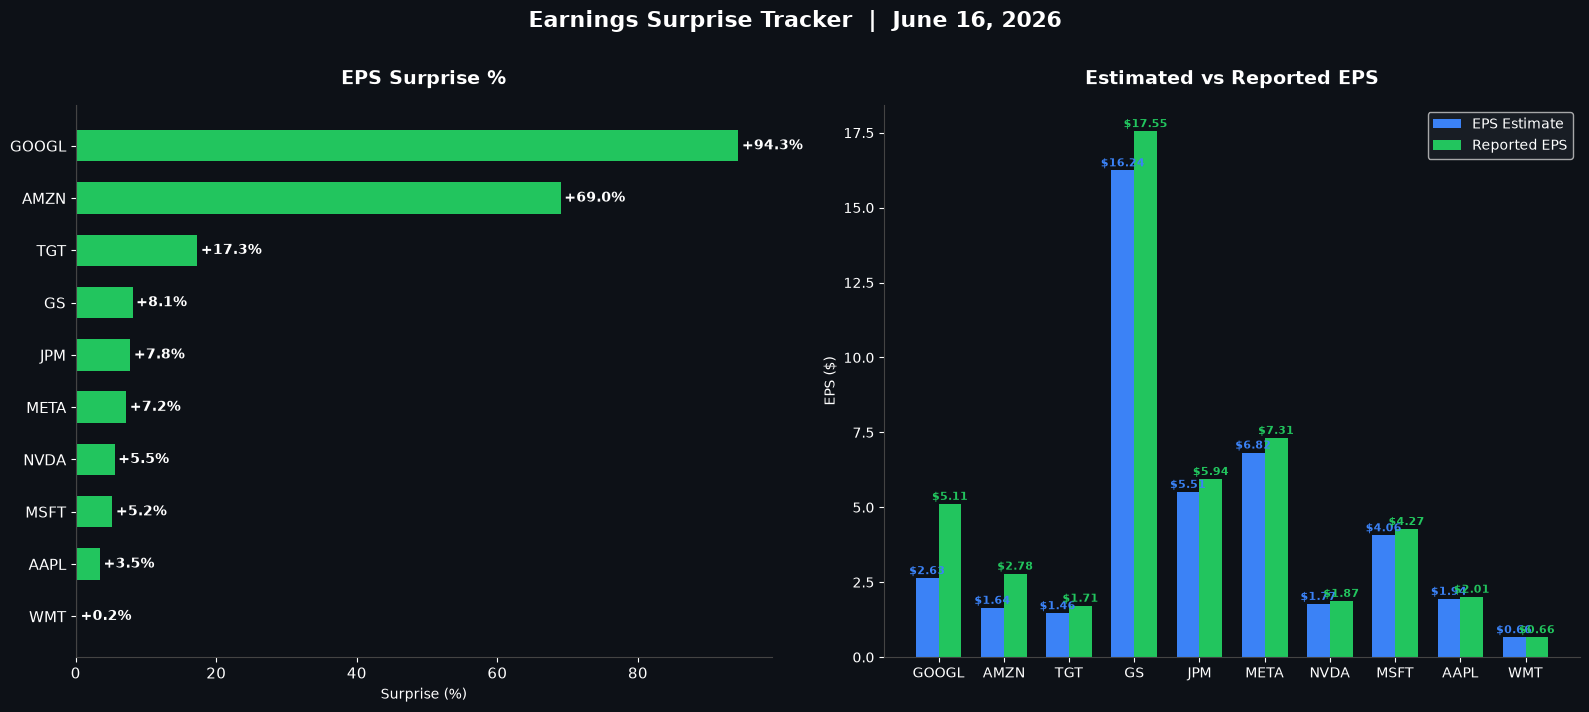

Chart saved as earnings_tracker.png


In [11]:
# ============================================================
# EARNINGS SURPRISE TRACKER VISUALIZATION
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(16, 7))
fig.patch.set_facecolor('#0d1117')

# --- LEFT: Surprise % Bar Chart ---
ax1 = axes[0]
ax1.set_facecolor('#0d1117')

sorted_df = earnings_df.sort_values('Surprise %', ascending=True)
colors = ['#ef4444' if x < 0 else '#22c55e' for x in sorted_df['Surprise %']]

bars = ax1.barh(sorted_df['Ticker'], sorted_df['Surprise %'], color=colors, height=0.6, edgecolor='none')

for bar, val in zip(bars, sorted_df['Surprise %']):
    ax1.text(
        val + 0.5,
        bar.get_y() + bar.get_height() / 2,
        f'{val:+.1f}%',
        va='center', ha='left',
        color='white', fontsize=10, fontweight='bold'
    )

ax1.axvline(0, color='white', linewidth=0.8, alpha=0.5)
ax1.set_title('EPS Surprise %', color='white', fontsize=14, fontweight='bold', pad=15)
ax1.tick_params(colors='white', labelsize=11)
ax1.set_xlabel('Surprise (%)', color='white', fontsize=10)
ax1.spines['bottom'].set_color('#444')
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)
ax1.spines['left'].set_color('#444')
plt.setp(ax1.get_yticklabels(), color='white')

# --- RIGHT: Estimated vs Reported EPS Grouped Bar ---
ax2 = axes[1]
ax2.set_facecolor('#0d1117')

x = np.arange(len(earnings_df))
width = 0.35

bars1 = ax2.bar(x - width/2, earnings_df['EPS Estimate'], width, label='EPS Estimate',
                color='#3b82f6', edgecolor='none')
bars2 = ax2.bar(x + width/2, earnings_df['Reported EPS'], width, label='Reported EPS',
                color='#22c55e', edgecolor='none')

ax2.set_xticks(x)
ax2.set_xticklabels(earnings_df['Ticker'], color='white', fontsize=10)
ax2.set_title('Estimated vs Reported EPS', color='white', fontsize=14, fontweight='bold', pad=15)
ax2.set_ylabel('EPS ($)', color='white', fontsize=10)
ax2.tick_params(colors='white')
ax2.legend(facecolor='#1c2128', labelcolor='white', fontsize=10, framealpha=0.8)
ax2.spines['bottom'].set_color('#444')
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)
ax2.spines['left'].set_color('#444')
plt.setp(ax2.get_yticklabels(), color='white')

# Add value labels on bars
for bar in bars1:
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05,
             f'${bar.get_height():.2f}', ha='center', va='bottom',
             color='#3b82f6', fontsize=8, fontweight='bold')
for bar in bars2:
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05,
             f'${bar.get_height():.2f}', ha='center', va='bottom',
             color='#22c55e', fontsize=8, fontweight='bold')

today = datetime.today().strftime('%B %d, %Y')
fig.suptitle(f'Earnings Surprise Tracker  |  {today}', color='white',
             fontsize=16, fontweight='bold', y=1.01)

plt.tight_layout()
plt.savefig('earnings_tracker.png', dpi=150, bbox_inches='tight', facecolor='#0d1117')
plt.show()
print("Chart saved as earnings_tracker.png")

In [12]:
cd market-dashboard

[Errno 2] No such file or directory: 'market-dashboard'
/Users/marvinpatel


In [13]:
cd market_dashboard

[Errno 2] No such file or directory: 'market_dashboard'
/Users/marvinpatel


In [14]:
mkdir market-dashboard

In [15]:
cp ~/market_dashboard.ipynb ~/market-dashboard/
cp ~/sector_rotation.png ~/market-dashboard/
cp ~/earnings_tracker.png ~/market-dashboard/

SyntaxError: invalid syntax (2726689420.py, line 1)